# MNIST DDPM: Unconditional Baseline and Conditional Extension

This notebook implements two MNIST diffusion experiments:

1. **Unconditional MNIST DDPM baseline**

   This matches the original homework formulation:

   $$
   \epsilon_\theta(x_t, t)
   $$

   The model receives a noisy image `x_t` and timestep `t`, then predicts the Gaussian noise added to the image.

2. **Conditional MNIST DDPM extension**

   This extends the baseline by adding the digit label `y`:

   $$
   \epsilon_\theta(x_t, t, y)
   $$

   The model receives a noisy image `x_t`, timestep `t`, and digit label `y`, then predicts the added Gaussian noise. During sampling, we can specify a digit label such as `7` and generate handwritten digits of that class from pure Gaussian noise.

Both models use the same DDPM noise prediction objective:

$$
L = \|\epsilon - \epsilon_\theta(\cdot)\|^2
$$

The notebook saves:

- `outputs/mnist_dataset_preview.png`
- `outputs/mnist_preview_label_distribution.png`
- `outputs/forward_noising_grid.png`
- `outputs/unconditional_generated_digits.png`
- `outputs/unconditional_loss_curve.png`
- `outputs/reverse_denoising_trajectory.png`
- `outputs/conditional_generated_digits.png`
- `outputs/loss_curve.png`


## Module 1: Imports and Configuration

This section imports PyTorch, torchvision, and plotting tools. It also defines all hyperparameters in one place.

Important settings:

- `T = 200`: number of diffusion steps, matching the assignment requirement.
- `BETA_START` and `BETA_END`: linear beta schedule endpoints.
- `EPOCHS = 50`: more training usually gives clearer conditional samples.
- `NUM_WORKERS = 0`: safer for Jupyter notebooks on macOS because multiprocessing can cause pickling issues.

In [1]:
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image

# Reproducibility
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

# Output folder
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Diffusion settings
T = 200
BETA_START = 1e-4
BETA_END = 0.05

# Training settings
BATCH_SIZE = 128
EPOCHS = 50
LR = 1e-3
BASE_CHANNELS = 64
EMA_DECAY = 0.995
NUM_WORKERS = 0

# Sampling settings
SAMPLES_PER_DIGIT = 2
TRAJECTORY_DIGIT = 7

# Device selection
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

device

device(type='mps')

## Module 2: Download and Preprocess MNIST

MNIST images are 28x28 grayscale handwritten digits. The assignment requires the images to be normalized to `[-1, 1]`.

`transforms.ToTensor()` converts pixels from `[0, 255]` to `[0, 1]`.

Then:

$$
\text{Normalize}(0.5, 0.5) = \frac{x - 0.5}{0.5} = 2x - 1
$$

so the final image range becomes `[-1, 1]`.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

train_dataset = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    drop_last=True,
)

x_example, y_example = next(iter(train_loader))
print("Image batch shape:", x_example.shape)
print("Label batch shape:", y_example.shape)
print("First labels:", y_example[:16].tolist())

Image batch shape: torch.Size([128, 1, 28, 28])
Label batch shape: torch.Size([128])
First labels: [1, 2, 8, 5, 2, 6, 9, 9, 9, 4, 0, 3, 9, 9, 5, 6]


## Module 3: Dataset Preview and Sanity Checks

Before training the diffusion model, we preview the MNIST data to confirm that the input pipeline is correct.

This section checks three things:

1. **Image appearance**: the samples should look like handwritten digits.
2. **Labels**: each displayed image should have a label from 0 to 9.
3. **Normalization**: the tensor values used for training should be in `[-1, 1]`.

For display only, the images are denormalized back to `[0, 1]` using:

$$
x_{display} = \frac{x_{train} + 1}{2}
$$

This does not change the training data. It only makes the images easier to visualize with matplotlib.

Training tensor shape: torch.Size([25, 1, 28, 28])
Training tensor min: -1.0
Training tensor max: 1.0
Training tensor mean: -0.7334966063499451
Training tensor std: 0.6167457699775696
Preview labels: [1, 2, 8, 5, 2, 6, 9, 9, 9, 4, 0, 3, 9, 9, 5, 6, 7, 8, 8, 9, 2, 6, 9, 3, 0]


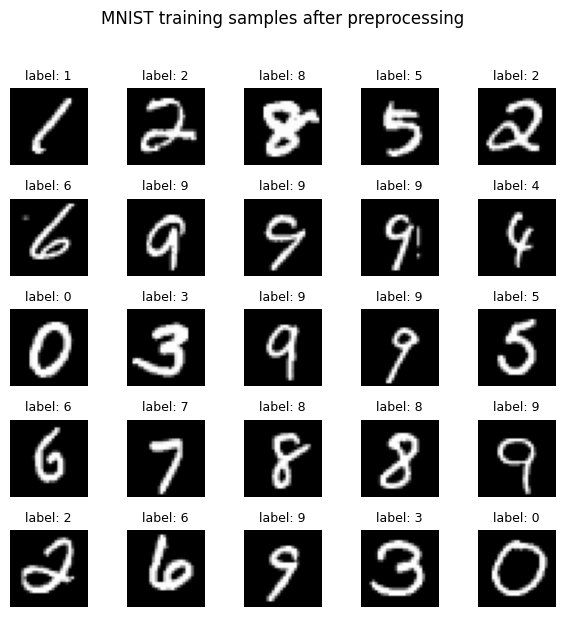

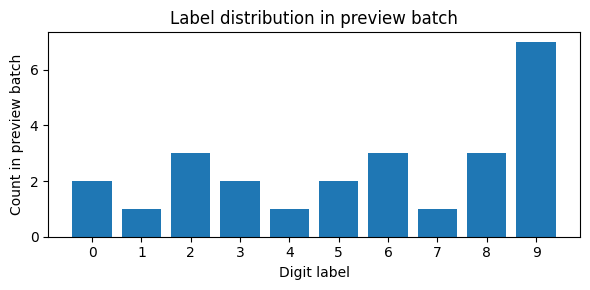

In [3]:
# Take a small batch from the training loader.
preview_batch_size = 25
preview_images_train = x_example[:preview_batch_size]
preview_labels = y_example[:preview_batch_size]

# Check the actual tensor range used for training.
print("Training tensor shape:", preview_images_train.shape)
print("Training tensor min:", preview_images_train.min().item())
print("Training tensor max:", preview_images_train.max().item())
print("Training tensor mean:", preview_images_train.mean().item())
print("Training tensor std:", preview_images_train.std().item())
print("Preview labels:", preview_labels.tolist())

# Denormalize only for visualization. This local helper is defined here
# because the main denormalize() function is introduced later with the diffusion schedule.
def denormalize_for_display(x):
    return (x.clamp(-1, 1) + 1) / 2

preview_images_display = denormalize_for_display(preview_images_train)

fig, axes = plt.subplots(5, 5, figsize=(6, 6))
for ax, image, label in zip(axes.flat, preview_images_display, preview_labels):
    ax.imshow(image.squeeze(), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"label: {label.item()}", fontsize=9)
    ax.axis("off")
plt.suptitle("MNIST training samples after preprocessing", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "mnist_dataset_preview.png", dpi=160, bbox_inches="tight")
plt.show()

# Show label counts in this preview batch.
label_counts = torch.bincount(preview_labels, minlength=10)
plt.figure(figsize=(6, 3))
plt.bar(range(10), label_counts.tolist())
plt.xticks(range(10))
plt.xlabel("Digit label")
plt.ylabel("Count in preview batch")
plt.title("Label distribution in preview batch")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "mnist_preview_label_distribution.png", dpi=160)
plt.show()

## Module 4: Diffusion Schedule

The forward diffusion process gradually adds Gaussian noise to a clean image. We use a linear beta schedule:

$$
\beta_1, \beta_2, \dots, \beta_T
$$

Then:

$$
\alpha_t = 1 - \beta_t
$$

and:

$$
\bar{\alpha}_t = \prod_{s=1}^{t}\alpha_s
$$

For `T=200`, `BETA_END=0.05` makes the final noised image close to Gaussian noise. This helps match the sampling process, which starts from pure Gaussian noise.

In [4]:
betas = torch.linspace(BETA_START, BETA_END, T, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)
alpha_bars_prev = F.pad(alpha_bars[:-1], (1, 0), value=1.0)

# Posterior variance used during reverse sampling.
posterior_variance = betas * (1.0 - alpha_bars_prev) / (1.0 - alpha_bars)
posterior_variance = posterior_variance.clamp(min=1e-20)

sqrt_alpha_bars = torch.sqrt(alpha_bars)
sqrt_one_minus_alpha_bars = torch.sqrt(1.0 - alpha_bars)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

print(f"Final alpha_bar: {alpha_bars[-1].item():.6f}")
print(f"The final forward image keeps about {alpha_bars[-1].item() * 100:.2f}% of the original signal variance.")

Final alpha_bar: 0.006122
The final forward image keeps about 0.61% of the original signal variance.


## Module 5: Forward Noising Function

The forward process samples a noisy image directly at any timestep $t$:

$$
x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1 - \bar{\alpha}_t}\epsilon
$$

where $\epsilon \sim \mathcal{N}(0, I)$.

The function returns both `x_t` and the true noise `epsilon`, because the training target is the true noise.

In [5]:
def gather(values, t, x_shape):
    selected = values.gather(0, t)
    return selected.view(t.shape[0], *((1,) * (len(x_shape) - 1)))


def add_noise(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)

    sqrt_alpha_bar_t = gather(sqrt_alpha_bars, t, x0.shape)
    sqrt_one_minus_alpha_bar_t = gather(sqrt_one_minus_alpha_bars, t, x0.shape)
    xt = sqrt_alpha_bar_t * x0 + sqrt_one_minus_alpha_bar_t * noise
    return xt, noise

def denormalize(x):
    return (x.clamp(-1, 1) + 1) / 2


## Module 6: Forward Noising Visualization

This grid shows one real MNIST image becoming noisier over time. This corresponds to the assignment requirement for a forward noising grid.

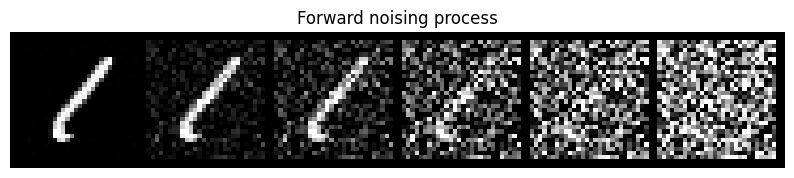

In [6]:
if "denormalize" not in globals():
    def denormalize(x):
        return (x.clamp(-1, 1) + 1) / 2

x0 = x_example[:1].to(device)
fixed_noise = torch.randn_like(x0)
forward_steps = [0, 20, 40, 80, 120, T - 1]
noisy_images = []

for step in forward_steps:
    t = torch.tensor([step], device=device, dtype=torch.long)
    xt, _ = add_noise(x0, t, noise=fixed_noise)
    noisy_images.append(xt.cpu())

forward_grid = make_grid(denormalize(torch.cat(noisy_images, dim=0)), nrow=len(forward_steps), padding=2)
save_image(forward_grid, OUTPUT_DIR / "forward_noising_grid.png")

plt.figure(figsize=(10, 2))
plt.imshow(forward_grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.title("Forward noising process")
plt.axis("off")
plt.show()

## Module 7: Conditional Denoising Network

The model predicts the noise added to the image:

$$
\epsilon_\theta(x_t, t, y)
$$

It receives three inputs:

- `xt`: noisy image, shape `[batch_size, 1, 28, 28]`
- `t`: timestep, shape `[batch_size]`
- `y`: digit label, shape `[batch_size]`

The model contains:

- a sinusoidal timestep embedding,
- a digit label embedding,
- a small CNN with downsampling and upsampling,
- an output layer that predicts noise with shape `[batch_size, 1, 28, 28]`.

In [7]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        scale = math.log(10000) / max(half_dim - 1, 1)
        frequencies = torch.exp(torch.arange(half_dim, device=t.device) * -scale)
        angles = t.float().unsqueeze(1) * frequencies.unsqueeze(0)
        embedding = torch.cat([torch.sin(angles), torch.cos(angles)], dim=1)
        if self.dim % 2 == 1:
            embedding = F.pad(embedding, (0, 1))
        return embedding


class ConditionalDenoiseCNN(nn.Module):
    def __init__(self, num_classes=10, base_channels=64, emb_dim=128):
        super().__init__()
        self.time_embedding = nn.Sequential(
            SinusoidalTimeEmbedding(emb_dim),
            nn.Linear(emb_dim, emb_dim),
            nn.SiLU(),
        )
        self.label_embedding = nn.Embedding(num_classes, emb_dim)

        self.conv_in = nn.Conv2d(1, base_channels, kernel_size=3, padding=1)
        self.block1 = self.make_block(base_channels, base_channels)
        self.down = nn.Conv2d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1)
        self.block2 = self.make_block(base_channels * 2, base_channels * 2)
        self.up = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=4, stride=2, padding=1)
        self.block3 = self.make_block(base_channels * 2, base_channels)
        self.conv_out = nn.Conv2d(base_channels, 1, kernel_size=3, padding=1)

        self.condition1 = nn.Linear(emb_dim, base_channels)
        self.condition2 = nn.Linear(emb_dim, base_channels * 2)
        self.condition3 = nn.Linear(emb_dim, base_channels)

    @staticmethod
    def make_block(in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
        )

    @staticmethod
    def add_condition(feature_map, condition):
        return feature_map + condition[:, :, None, None]

    def forward(self, xt, t, y):
        condition = self.time_embedding(t) + self.label_embedding(y)

        h1 = self.conv_in(xt)
        h1 = self.add_condition(h1, self.condition1(condition))
        h1 = self.block1(h1)

        h2 = self.down(h1)
        h2 = self.add_condition(h2, self.condition2(condition))
        h2 = self.block2(h2)

        h3 = self.up(h2)
        h3 = torch.cat([h3, h1], dim=1)
        h3 = self.block3(h3)
        h3 = self.add_condition(h3, self.condition3(condition))

        return self.conv_out(h3)


model = ConditionalDenoiseCNN(base_channels=BASE_CHANNELS).to(device)
ema_model = ConditionalDenoiseCNN(base_channels=BASE_CHANNELS).to(device)
ema_model.load_state_dict(model.state_dict())

for parameter in ema_model.parameters():
    parameter.requires_grad_(False)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

# Shape check
sample_t = torch.randint(0, T, (BATCH_SIZE,), device=device)
sample_y = y_example.to(device)
sample_output = model(x_example.to(device), sample_t, sample_y)
print("Model output shape:", sample_output.shape)

Model output shape: torch.Size([128, 1, 28, 28])


## Module 8: EMA Helper

EMA means Exponential Moving Average. During training, we keep a smoothed copy of the model parameters.

The EMA model often produces cleaner samples than the raw training model, so sampling uses `ema_model`.

In [8]:
def update_ema(ema_model, model, decay=EMA_DECAY):
    with torch.no_grad():
        for ema_parameter, parameter in zip(ema_model.parameters(), model.parameters()):
            ema_parameter.data.mul_(decay).add_(parameter.data, alpha=1.0 - decay)

## Module 8A: Unconditional DDPM Baseline

This optional baseline matches the original homework formulation exactly:

$$
\epsilon_\theta(x_t, t)
$$

Unlike the conditional model, this model does **not** receive the digit label `y`. It only receives:

- noisy image `x_t`
- timestep `t`

The training objective is still the same noise prediction loss:

$$
L = \|\epsilon - \epsilon_\theta(x_t,t)\|^2
$$

This module is useful because it shows the direct minimal MNIST DDPM required by the slides, while the later conditional model extends it by adding label conditioning.

In [9]:
class UnconditionalDenoiseCNN(nn.Module):
    def __init__(self, base_channels=64, emb_dim=128):
        super().__init__()
        self.time_embedding = nn.Sequential(
            SinusoidalTimeEmbedding(emb_dim),
            nn.Linear(emb_dim, emb_dim),
            nn.SiLU(),
        )

        self.conv_in = nn.Conv2d(1, base_channels, kernel_size=3, padding=1)
        self.block1 = ConditionalDenoiseCNN.make_block(base_channels, base_channels)
        self.down = nn.Conv2d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1)
        self.block2 = ConditionalDenoiseCNN.make_block(base_channels * 2, base_channels * 2)
        self.up = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=4, stride=2, padding=1)
        self.block3 = ConditionalDenoiseCNN.make_block(base_channels * 2, base_channels)
        self.conv_out = nn.Conv2d(base_channels, 1, kernel_size=3, padding=1)

        self.condition1 = nn.Linear(emb_dim, base_channels)
        self.condition2 = nn.Linear(emb_dim, base_channels * 2)
        self.condition3 = nn.Linear(emb_dim, base_channels)

    def forward(self, xt, t):
        condition = self.time_embedding(t)

        h1 = self.conv_in(xt)
        h1 = ConditionalDenoiseCNN.add_condition(h1, self.condition1(condition))
        h1 = self.block1(h1)

        h2 = self.down(h1)
        h2 = ConditionalDenoiseCNN.add_condition(h2, self.condition2(condition))
        h2 = self.block2(h2)

        h3 = self.up(h2)
        h3 = torch.cat([h3, h1], dim=1)
        h3 = self.block3(h3)
        h3 = ConditionalDenoiseCNN.add_condition(h3, self.condition3(condition))

        return self.conv_out(h3)


uncond_model = UnconditionalDenoiseCNN(base_channels=BASE_CHANNELS).to(device)
uncond_ema_model = UnconditionalDenoiseCNN(base_channels=BASE_CHANNELS).to(device)
uncond_ema_model.load_state_dict(uncond_model.state_dict())
for parameter in uncond_ema_model.parameters():
    parameter.requires_grad_(False)

uncond_optimizer = torch.optim.AdamW(uncond_model.parameters(), lr=LR)

sample_t = torch.randint(0, T, (BATCH_SIZE,), device=device)
uncond_sample_output = uncond_model(x_example.to(device), sample_t)
print("Unconditional model output shape:", uncond_sample_output.shape)

Unconditional model output shape: torch.Size([128, 1, 28, 28])


## Module 8B: Train the Unconditional Baseline

To keep the notebook practical, this baseline uses fewer epochs than the main conditional model. It is included to demonstrate the original homework setting.

The conditional model later is the main experiment because it can generate digits controlled by labels from 0 to 9.

In [10]:
TRAIN_UNCONDITIONAL_BASELINE = True
UNCONDITIONAL_EPOCHS = 50
unconditional_losses = []

if TRAIN_UNCONDITIONAL_BASELINE:
    uncond_model.train()
    uncond_step = 0

    for epoch in range(UNCONDITIONAL_EPOCHS):
        for x0, _ in train_loader:
            x0 = x0.to(device)
            t = torch.randint(0, T, (x0.shape[0],), device=device, dtype=torch.long)
            xt, true_noise = add_noise(x0, t)

            predicted_noise = uncond_model(xt, t)
            loss = F.mse_loss(predicted_noise, true_noise)

            uncond_optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(uncond_model.parameters(), 1.0)
            uncond_optimizer.step()
            update_ema(uncond_ema_model, uncond_model)

            unconditional_losses.append(loss.item())
            uncond_step += 1

            if uncond_step % 100 == 0:
                print(f"unconditional epoch={epoch + 1:02d}/{UNCONDITIONAL_EPOCHS} step={uncond_step:05d} loss={loss.item():.4f}")

    torch.save({
        "model_state_dict": uncond_model.state_dict(),
        "ema_model_state_dict": uncond_ema_model.state_dict(),
        "timesteps": T,
        "beta_start": BETA_START,
        "beta_end": BETA_END,
        "base_channels": BASE_CHANNELS,
        "losses": unconditional_losses,
    }, OUTPUT_DIR / "unconditional_ddpm_mnist.pth")
else:
    print("Skipped unconditional baseline training.")

unconditional epoch=01/10 step=00100 loss=0.0595
unconditional epoch=01/10 step=00200 loss=0.0610
unconditional epoch=01/10 step=00300 loss=0.0514
unconditional epoch=01/10 step=00400 loss=0.0451
unconditional epoch=02/10 step=00500 loss=0.0468
unconditional epoch=02/10 step=00600 loss=0.0392
unconditional epoch=02/10 step=00700 loss=0.0416
unconditional epoch=02/10 step=00800 loss=0.0412
unconditional epoch=02/10 step=00900 loss=0.0348
unconditional epoch=03/10 step=01000 loss=0.0453
unconditional epoch=03/10 step=01100 loss=0.0359
unconditional epoch=03/10 step=01200 loss=0.0411
unconditional epoch=03/10 step=01300 loss=0.0429
unconditional epoch=03/10 step=01400 loss=0.0459
unconditional epoch=04/10 step=01500 loss=0.0346
unconditional epoch=04/10 step=01600 loss=0.0380
unconditional epoch=04/10 step=01700 loss=0.0381
unconditional epoch=04/10 step=01800 loss=0.0365
unconditional epoch=05/10 step=01900 loss=0.0399
unconditional epoch=05/10 step=02000 loss=0.0385
unconditional epoch=

## Module 8B.1: Unconditional Loss Curve

This plot shows the training loss of the unconditional DDPM baseline. It is separate from the conditional loss curve, so the two experiments can be reported independently.


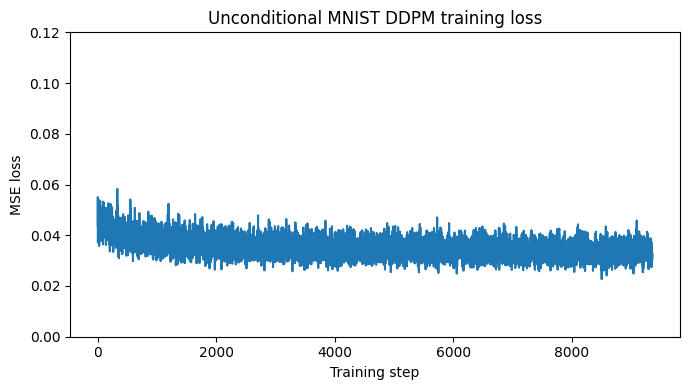

In [49]:
if len(unconditional_losses) > 0:
    plt.figure(figsize=(7, 4))
    plt.plot(unconditional_losses, linewidth=1.5)
    plt.xlabel("Training step")
    plt.ylabel("MSE loss")
    plt.title("Unconditional MNIST DDPM training loss")
    plt.ylim(0.0, 0.12)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "unconditional_loss_curve.png", dpi=160)
    plt.show()
else:
    print("No unconditional losses found. Run Module 8B first.")


## Module 8C: Unconditional Sampling Preview

The unconditional model samples MNIST-like digits without label control. This contrasts with the conditional model, where each row can be forced to represent a chosen digit label.

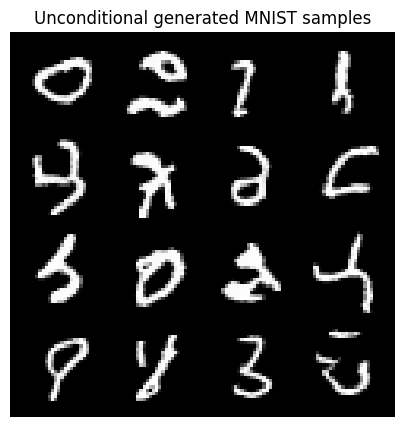

In [11]:
if TRAIN_UNCONDITIONAL_BASELINE:
    # Use the same visual layout as the conditional grid: 10 rows x 2 columns.
    # These samples are not label-controlled; row numbers are only sample group indices.
    uncond_rows = 10
    uncond_cols = SAMPLES_PER_DIGIT
    uncond_images = denormalize(sample_unconditional(num_samples=uncond_rows * uncond_cols))

    fig, axes = plt.subplots(uncond_rows, uncond_cols, figsize=(uncond_cols * 1.4, 12))
    for row in range(uncond_rows):
        for col in range(uncond_cols):
            index = row * uncond_cols + col
            ax = axes[row, col]
            ax.imshow(uncond_images[index].squeeze(), cmap="gray")
            ax.axis("off")
            if col == 0:
                ax.set_ylabel(f"row {row}", rotation=0, labelpad=22, fontsize=9)

    plt.suptitle("Unconditional generated MNIST samples", y=0.995)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "unconditional_generated_digits.png", dpi=160)
    plt.show()
else:
    print("No unconditional samples because baseline training was skipped.")


## Module 9: Training Loop

For each batch:

1. Load clean images `x0` and labels `y`.
2. Randomly sample a timestep `t`.
3. Add Gaussian noise to obtain `xt`.
4. Predict noise with `model(xt, t, y)`.
5. Minimize MSE between predicted noise and true noise.

The loss is:

$$
L = \|\epsilon - \epsilon_\theta(x_t,t,y)\|^2
$$

In [12]:
losses = []
global_step = 0

model.train()
for epoch in range(EPOCHS):
    for x0, y in train_loader:
        x0 = x0.to(device)
        y = y.to(device)
        t = torch.randint(0, T, (x0.shape[0],), device=device, dtype=torch.long)
        xt, true_noise = add_noise(x0, t)

        predicted_noise = model(xt, t, y)
        loss = F.mse_loss(predicted_noise, true_noise)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        update_ema(ema_model, model)

        losses.append(loss.item())
        global_step += 1

        if global_step % 100 == 0:
            print(f"epoch={epoch + 1:02d}/{EPOCHS} step={global_step:05d} loss={loss.item():.4f}")

checkpoint = {
    "model_state_dict": model.state_dict(),
    "ema_model_state_dict": ema_model.state_dict(),
    "timesteps": T,
    "beta_start": BETA_START,
    "beta_end": BETA_END,
    "base_channels": BASE_CHANNELS,
    "losses": losses,
}
torch.save(checkpoint, OUTPUT_DIR / "conditional_ddpm_mnist.pth")

epoch=01/50 step=00100 loss=0.0705
epoch=01/50 step=00200 loss=0.0549
epoch=01/50 step=00300 loss=0.0566
epoch=01/50 step=00400 loss=0.0376
epoch=02/50 step=00500 loss=0.0425
epoch=02/50 step=00600 loss=0.0365
epoch=02/50 step=00700 loss=0.0457
epoch=02/50 step=00800 loss=0.0380
epoch=02/50 step=00900 loss=0.0360
epoch=03/50 step=01000 loss=0.0424
epoch=03/50 step=01100 loss=0.0486
epoch=03/50 step=01200 loss=0.0385
epoch=03/50 step=01300 loss=0.0288
epoch=03/50 step=01400 loss=0.0402
epoch=04/50 step=01500 loss=0.0333
epoch=04/50 step=01600 loss=0.0417
epoch=04/50 step=01700 loss=0.0383
epoch=04/50 step=01800 loss=0.0346
epoch=05/50 step=01900 loss=0.0366
epoch=05/50 step=02000 loss=0.0371
epoch=05/50 step=02100 loss=0.0371
epoch=05/50 step=02200 loss=0.0303
epoch=05/50 step=02300 loss=0.0405
epoch=06/50 step=02400 loss=0.0359
epoch=06/50 step=02500 loss=0.0401
epoch=06/50 step=02600 loss=0.0388
epoch=06/50 step=02700 loss=0.0411
epoch=06/50 step=02800 loss=0.0335
epoch=07/50 step=029

## Module 10: Loss Curve

The loss curve shows whether the noise prediction model is learning. It does not have to be perfectly smooth, but it should generally decrease.

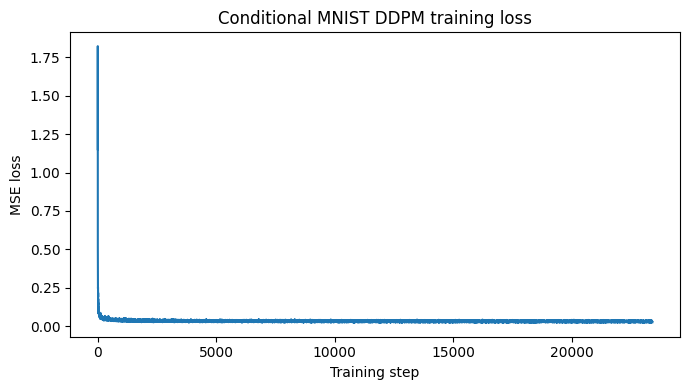

In [13]:
plt.figure(figsize=(7, 4))
plt.plot(losses, linewidth=1.5)
plt.xlabel("Training step")
plt.ylabel("MSE loss")
plt.title("Conditional MNIST DDPM training loss")
plt.ylim(0.0, 0.12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "loss_curve.png", dpi=160)
plt.show()

## Module 10A: Side-by-Side Loss Curves

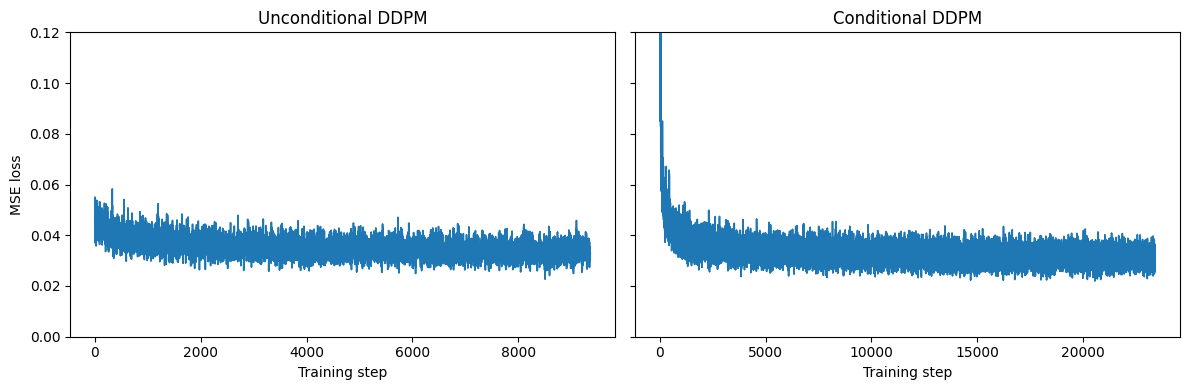

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

if "unconditional_losses" in globals() and len(unconditional_losses) > 0:
    axes[0].plot(unconditional_losses, linewidth=1.2)
else:
    axes[0].text(0.5, 0.5, "Run Module 8B first", ha="center", va="center", transform=axes[0].transAxes)
axes[0].set_title("Unconditional DDPM")
axes[0].set_xlabel("Training step")
axes[0].set_ylabel("MSE loss")
axes[0].set_ylim(0.0, 0.12)

if "losses" in globals() and len(losses) > 0:
    axes[1].plot(losses, linewidth=1.2)
else:
    axes[1].text(0.5, 0.5, "Run Module 9 first", ha="center", va="center", transform=axes[1].transAxes)
axes[1].set_title("Conditional DDPM")
axes[1].set_xlabel("Training step")
axes[1].set_ylim(0.0, 0.12)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "loss_curves_side_by_side.png", dpi=160)
plt.show()


## Module 11: Conditional Sampling Function

Sampling starts from pure Gaussian noise:

$$
x_T \sim \mathcal{N}(0, I)
$$

Then the model repeatedly predicts and removes noise from timestep `T-1` down to `0`.

The label `y` is provided during every denoising step, so the model can generate a specified digit class.

In [14]:
@torch.no_grad()
def sample(labels, image_size=28):
    sampling_model = ema_model if "ema_model" in globals() else model
    sampling_model.eval()

    labels = labels.to(device)
    x = torch.randn(labels.shape[0], 1, image_size, image_size, device=device)
    snapshots = {T - 1: x.detach().cpu()}

    for step in reversed(range(T)):
        t = torch.full((labels.shape[0],), step, device=device, dtype=torch.long)
        predicted_noise = sampling_model(x, t, labels)

        beta_t = gather(betas, t, x.shape)
        posterior_variance_t = gather(posterior_variance, t, x.shape)
        sqrt_one_minus_alpha_bar_t = gather(sqrt_one_minus_alpha_bars, t, x.shape)
        sqrt_recip_alpha_t = gather(sqrt_recip_alphas, t, x.shape)

        mean = sqrt_recip_alpha_t * (x - beta_t * predicted_noise / sqrt_one_minus_alpha_bar_t)

        if step > 0:
            x = mean + torch.sqrt(posterior_variance_t) * torch.randn_like(x)
        else:
            x = mean

        snapshots[step] = x.detach().cpu()

    return x.detach().cpu(), snapshots

## Module 12: Reverse Denoising Trajectory

This visualization shows the reverse denoising process for one chosen label, for example digit `7`:

$$
x_T \rightarrow x_{150} \rightarrow x_{100} \rightarrow x_{50} \rightarrow x_0
$$

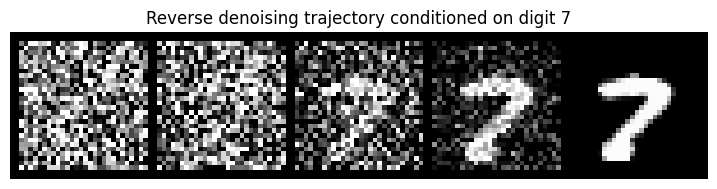

In [15]:
trajectory_label = torch.tensor([TRAJECTORY_DIGIT], dtype=torch.long)
_, trajectory_snapshots = sample(trajectory_label)
trajectory_steps = [T - 1, 150, 100, 50, 0]
trajectory_images = torch.cat([trajectory_snapshots[step] for step in trajectory_steps], dim=0)
trajectory_grid = make_grid(denormalize(trajectory_images), nrow=len(trajectory_steps), padding=2)
save_image(trajectory_grid, OUTPUT_DIR / "reverse_denoising_trajectory.png")

plt.figure(figsize=(9, 2))
plt.imshow(trajectory_grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.title(f"Reverse denoising trajectory conditioned on digit {TRAJECTORY_DIGIT}")
plt.axis("off")
plt.show()

## Module 13: Conditional Generated Digit Grid

This grid demonstrates conditional generation. Each row uses a fixed label from 0 to 9, and each row contains multiple generated samples for that label.

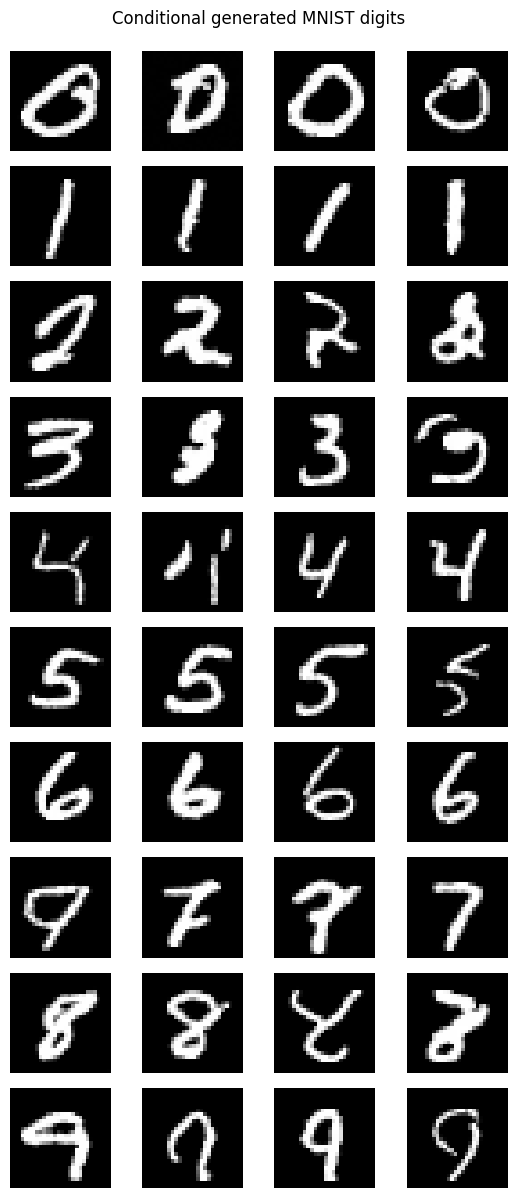

In [16]:
labels = torch.arange(10, dtype=torch.long).repeat_interleave(SAMPLES_PER_DIGIT)
generated_images, _ = sample(labels)
generated_images = denormalize(generated_images)

fig, axes = plt.subplots(10, SAMPLES_PER_DIGIT, figsize=(SAMPLES_PER_DIGIT * 1.4, 12))
for row in range(10):
    for col in range(SAMPLES_PER_DIGIT):
        index = row * SAMPLES_PER_DIGIT + col
        ax = axes[row, col]
        ax.imshow(generated_images[index].squeeze(), cmap="gray")
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(str(row), rotation=0, labelpad=15, fontsize=12)

plt.suptitle("Conditional generated MNIST digits", y=0.995)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "conditional_generated_digits.png", dpi=160)
plt.show()

## Module 13A: Compact Report Grids

This optional cell creates smaller grids.

- Conditional compact grid: 2 samples for each label from 0 to 9.
- Unconditional compact grid: 20 unconditional samples arranged as 10 rows and 2 columns for a similar layout.


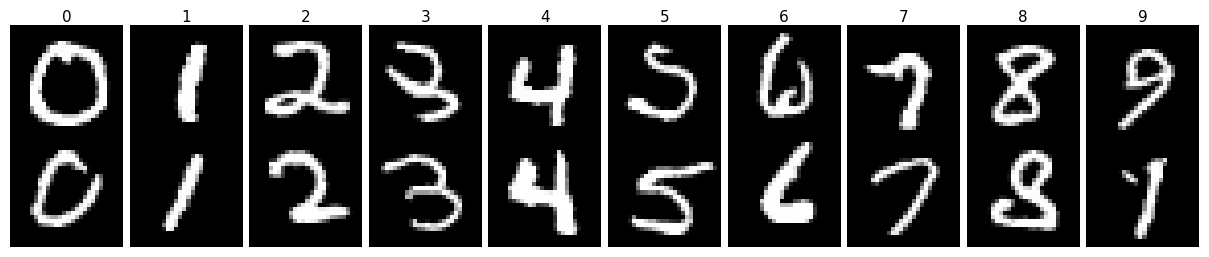

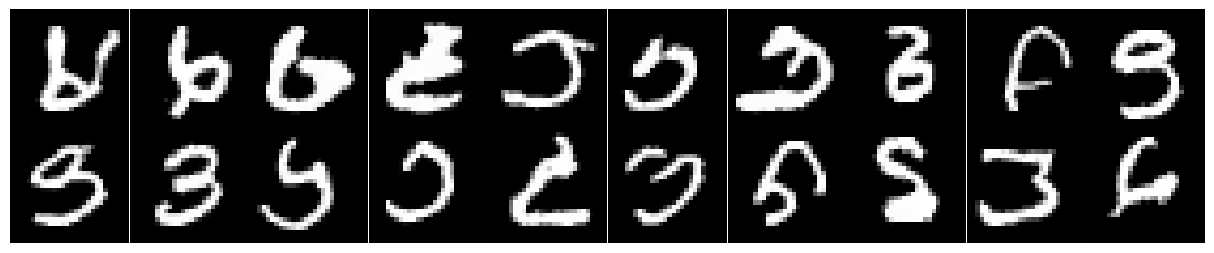

In [48]:
REPORT_SAMPLES_PER_DIGIT = 2

# Title-free conditional compact grid: two rows, labels 0-9 arranged horizontally.
report_labels = torch.arange(10, dtype=torch.long).repeat(REPORT_SAMPLES_PER_DIGIT)
report_conditional_images, _ = sample(report_labels)
report_conditional_images = denormalize(report_conditional_images)

fig, axes = plt.subplots(REPORT_SAMPLES_PER_DIGIT, 10, figsize=(12.0, 2.4))
for row in range(REPORT_SAMPLES_PER_DIGIT):
    for col in range(10):
        index = row * 10 + col
        ax = axes[row, col]
        ax.imshow(report_conditional_images[index].squeeze(), cmap="gray")
        ax.axis("off")
        if row == 0:
            ax.set_title(str(col), fontsize=11, pad=2)

plt.tight_layout(pad=0.2, w_pad=0.1, h_pad=0.1)
plt.savefig(OUTPUT_DIR / "conditional_generated_digits_compact_notitle.png", dpi=160, bbox_inches="tight", pad_inches=0.02)
plt.show()

# Title-free unconditional compact grid with the same horizontal layout.
if "sample_unconditional" in globals():
    report_unconditional_images = denormalize(sample_unconditional(num_samples=20))
    fig, axes = plt.subplots(REPORT_SAMPLES_PER_DIGIT, 10, figsize=(12.0, 2.4))
    for row in range(REPORT_SAMPLES_PER_DIGIT):
        for col in range(10):
            index = row * 10 + col
            ax = axes[row, col]
            ax.imshow(report_unconditional_images[index].squeeze(), cmap="gray")
            ax.axis("off")

    plt.tight_layout(pad=0.2, w_pad=0.1, h_pad=0.1)
    plt.savefig(OUTPUT_DIR / "unconditional_generated_digits_compact_notitle.png", dpi=160, bbox_inches="tight", pad_inches=0.02)
    plt.show()
else:
    print("sample_unconditional() is not defined. Run Module 8C first if you want the unconditional compact grid.")


## Module 14: Files Produced by This Notebook

After running all cells, the notebook saves:

- `outputs/mnist_dataset_preview.png`
- `outputs/mnist_preview_label_distribution.png`
- `outputs/forward_noising_grid.png`
- `outputs/reverse_denoising_trajectory.png`
- `outputs/conditional_generated_digits.png`
- `outputs/conditional_generated_digits_compact.png`
- `outputs/conditional_generated_digits_compact_notitle.png`
- `outputs/unconditional_generated_digits_compact.png`
- `outputs/unconditional_generated_digits_compact_notitle.png`
- `outputs/loss_curve.png`
- `outputs/loss_curve_comparison.png`
- `outputs/loss_curves_side_by_side.png`
- `outputs/conditional_ddpm_mnist.pth`
- `outputs/unconditional_generated_digits.png`
- `outputs/unconditional_loss_curve.png`
- `outputs/unconditional_ddpm_mnist.pth`